In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
installed = 0
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# imports

In [2]:
import os

if not installed:
    print("🔧 Step 1: Upgrading core packages...")
    print("="*70)
    !pip install -q --upgrade pip
    print("Updated 'pip' package...!")
    !pip install -q --upgrade google-cloud-vision
    print("Updated 'google cloud vision' package...!")
    !pip install -q --upgrade pip ipywidgets
    print("✅ Core packages upgraded.\n")
    
    print("🚀 Step 2: Installing/upgrading performance libraries (bitsandbytes, accelerate, transformers)...")
    print("="*70)
    !pip install -q -U bitsandbytes
    print("Updated 'bitsandbytes' package...!")
    !pip install -q -U accelerate
    print("Updated 'accelerate' package...!")
    !pip install -q -U transformers
    print("Updated 'transformers' package...!")
    print("✅ Performance libraries installed/upgraded.\n")
    
    print("🧠 Step 3: Installing OpenAI CLIP from GitHub...")
    print("="*70)
    !pip install -q git+https://github.com/openai/CLIP.git
    print("✅ OpenAI CLIP installed.\n")
    
    print("="*70)
    print("✅ All installations completed successfully!")
    print("🔄 Restarting kernel to apply changes...")
    installed = 1
else:
    print("All up to date!")

🔧 Step 1: Upgrading core packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.5 MB/s eta 0:00:0000:0100:01
Updated 'pip' package...!
Updated 'google cloud vision' package...!
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
bigframes 2.12.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.31.0, but you have google-cloud-bigquery 3.25.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.1.0 which is incompatible.
✅ Core packages upgraded.

🚀 Step 2: Installing/upgrading performance libraries (bitsandbytes, accelerate, transformers)...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libcug

In [ ]:
# os.kill(os.getpid(), 9)

In [1]:
import transformers
print(transformers.__version__)

4.57.0


In [2]:
# All Imports
# ----------------------------------------- GOOGLE OCR API -------------------------------------------
from google.cloud import vision
import io
from io import BytesIO

# ---------------------------------------- ESSENTIAL IMPORTS -----------------------------------------
import os
import time
import requests
import chardet
from tqdm.notebook import tqdm
import random

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from scipy.stats import mode

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, UnidentifiedImageError
import ast

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score

# ------------------------------------- DistilRoBERTa IMPORTS ----------------------------------------
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# ----------------------------------------- BLIP IMPORTS ---------------------------------------------
from transformers import BlipProcessor, BlipForConditionalGeneration

# ----------------------------------------- CLIP IMPORTS ---------------------------------------------
import clip

# ----------------------------------------- Torch IMPORTS --------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

print("\n","="*50)
print("All imports successful!")

2025-10-12 06:14:51.731350: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760249691.754908     146 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760249691.762018     146 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered



All imports successful!


In [3]:
# ----------------------------------------- Essentials ---------------------------------------------
# Replace with your actual path to the JSON key file
# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/kaggle/input/musait/manifest-canto-466706-v0-1bb68556dfe3.json"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/kaggle/input/musait/calcium-arcadia-474904-v2-3b546e247e07.json"

SENTIMENTS_TO_LABELS = {'negative':0,'neutral':1,'positive':2}
LABELS_TO_SENTIMENTS = {0:'negative',1:'neutral',2:"positive"}


# text_model_name = "distilroberta-base"
# text_model_name = "roberta-base"
text_model_name = "t5-base"
# text_model_name = "facebook/bart-base"

blip_model_name = "Salesforce/blip-image-captioning-base"

image_model_name = "ViT-B/32" # CLIP
# image_model_name = "xception"
# image_model_name = "ViT-L/16"

MAX_LENGTH = 128
num_classes = 3
embed_dim = 512


# Set the device to GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Google OCR environment ready to use!")

Google OCR environment ready to use!


In [4]:
name2model = {
    "distilroberta-base" : "/kaggle/input/best-models-musait/TSA/DistilRoBERTa__best_model.pt",
    "roberta-base" : "/kaggle/input/best-models-musait/TSA/RoBERTa__best_model.pt",
    "t5-base" : "/kaggle/input/best-models-musait/TSA/T5__best_model.pt",
    "facebook/bart-base" : "/kaggle/input/best-models-musait/TSA/bart__best_model.pt",
    "ViT-B/32" : "/kaggle/input/best-models-musait/VSA/CLIP__best_model.pt",
    "vit_large_patch16_224" : "/kaggle/input/best-models-musait/VSA/ViT-L__best_model.pt",
    "xception" : "/kaggle/input/best-models-musait/VSA/Xception__best_model.pt"
}

model2stdName = {
    "distilroberta-base" : "DistilRoBERTa",
    "roberta-base" : "RoBERTa",
    "t5-base" : "T5",
    "facebook/bart-base" : "BART",
    "ViT-B/32" : "CLIP",
    "vit_large_patch16_224" : "ViT-L/16",
    "xception" : "Xception"
}

# __ init __

In [5]:
# ================================ TEXT DETECTION ================================================

def check_text_detection_v1(image_path):
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    client = vision.ImageAnnotatorClient()
    
    image = vision.Image(content=content)
    text = None
    
    response = client.text_detection(image=image)
    texts = response.text_annotations
    return texts[0] if texts else False

def check_text_detection_v2(image_path):
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    client = vision.ImageAnnotatorClient()
    
    image = vision.Image(content=content)
    text = None
    
    response = client.text_detection(image=image)
    texts = response.text_annotations
    return texts if texts else False


# ================================ STANDARD ASPECT RATII ================================================

standard_ratios = {
    "1:1": 1.0,       # 1
    "4:3": 4/3,       # 1.33
    "3:2": 3/2,       # 1.5
    "16:9": 16/9,     # 1.78
    "5:4": 5/4,       # 1.25
    "21:9": 21/9,     # 2.33
    "2:1": 2.0,       # 2
    "7:5": 7/5,       # 1.4
    "1.41:1": 1.41,   # 1.41 (A4)
    "3:4": 3/4,       # 0.75
    "2:3": 2/3,       # 0.67
    "9:16": 9/16,     # 0.5625
    "5:7": 5/7,       # 0.71
    "4:5": 4/5,       # 0.8
    "1:√2": 1/1.414,  # 0.707 (A-series)
    "2:5": 2/5,       # 0.4
    "Other": 0
}


def closest_standard_ratio(width, height, tolerance=0.05):
    if height == 0:
        return "Invalid"
    ratio = width / height
    for name, std_ratio in standard_ratios.items():
        if abs(ratio - std_ratio) <= tolerance:
            return name
    return "Other"


# ================================ ASPECT RATIO - ORIENTATION ==========================================
    
aspect_ratio_orientation = {
    "1:1": "box",
    "4:3": "horizontal",      # 1.33
    "3:2": "horizontal",      # 1.5
    "16:9": "horizontal",     # 1.78
    "5:4": "horizontal",      # 1.25
    "21:9": "horizontal",     # 2.33
    "2:1": "horizontal",      # 2.0
    "7:5": "horizontal",      # 1.4
    "1.41:1": "horizontal",   # 1.41
    "3:4": "vertical",        # 0.75
    "2:3": "vertical",        # 0.666
    "9:16": "vertical",       # 0.5625
    "5:7": "vertical",        # 0.714
    "4:5": "vertical",        # 0.8
    "1:√2": "vertical",       # 0.707 (A-series)
    "2:5": "vertical",        # 0.4
    "Other": "box"
}

def image_orientation(image_path):
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    
    pil_image = Image.open(io.BytesIO(content))
    img_width, img_height = pil_image.size
    
    img_area = img_width * img_height
    img_ar = closest_standard_ratio(img_width, img_height)
    img_ort = aspect_ratio_orientation[img_ar]
    img_ort_sentiments = list(or_dist[img_ort])
    return img_ort_sentiments


def get_image_area(image_path):
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    
    pil_image = Image.open(io.BytesIO(content))
    img_width, img_height = pil_image.size
    img_area = img_width*img_height
    return img_area

def get_alpha_v2(texts, img_area):
    total_text_area = 0
    for t in texts[1:]:
        vertices = [(v.x, v.y) for v in t.bounding_poly.vertices]
        text_area = polygon_area(vertices)
        total_text_area += text_area
        print(f"Word: {t.description}, Area: {text_area}")
    
    print("Total Area:", total_text_area)
    alpha = total_text_area/img_area
    return alpha


def get_alpha_v1(texts, img_area):
    text = texts.description
    bounding_poly = texts.bounding_poly
    coordinates = []
    for vertex in bounding_poly.vertices:
        coordinates.append({"x": vertex.x, "y": vertex.y})
    
    x_values = [point['x'] for point in coordinates]
    y_values = [point['y'] for point in coordinates]
    txt_width = max(x_values) - min(x_values)
    txt_height = max(y_values) - min(y_values)

    txt_area = txt_width*txt_height
    txt_weightage = txt_area/img_area
    return txt_weightage

def text_orientation(texts, img_area):
    text = texts.description
    bounding_poly = texts.bounding_poly
    coordinates = []
    for vertex in bounding_poly.vertices:
        coordinates.append({"x": vertex.x, "y": vertex.y})
    
    x_values = [point['x'] for point in coordinates]
    y_values = [point['y'] for point in coordinates]
    txt_width = max(x_values) - min(x_values)
    txt_height = max(y_values) - min(y_values)

    txt_area = txt_width*txt_height
    txt_weightage = txt_area/img_area
    txt_ar = closest_standard_ratio(txt_width, txt_height)
    txt_ort = aspect_ratio_orientation[txt_ar]
    txt_ort_sentiments = list(or_dist[txt_ort])
    return txt_ort_sentiments, txt_weightage


# ========================================== TEXT MODEL ================================================

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(text_model_name)
text_model = AutoModelForSequenceClassification.from_pretrained(text_model_name, num_labels=num_classes)

text_model.to(device)

# Load your fine-tuned weights
state_dict = torch.load(name2model[text_model_name], map_location=device)
text_model.load_state_dict(state_dict)  # Should match now
text_model.eval()

def preprocess(text, tokenizer, max_length=128):
    return tokenizer(
        text,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )


text_tokenizer = AutoTokenizer.from_pretrained(text_model_name)



# ================================ GENERATION OF CAPTIONS ==============================================


blip_processor = BlipProcessor.from_pretrained(blip_model_name)
blip_model = BlipForConditionalGeneration.from_pretrained(blip_model_name).to(device)

blip_model.to(device)


# ========================================= IMAGE MODEL ================================================

class CLIPClassifier(nn.Module):
    def __init__(self, encoder, embed_dim, num_classes):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, image):
        image = image.to(dtype=self.encoder.conv1.weight.dtype)  # usually float16
        with torch.no_grad():
            x = self.encoder(image)
        x = x.float()  # Convert back to float32 for classifier
        return self.classifier(x)

clip_model, image_preprocess = clip.load(image_model_name, device=device)
image_encoder = clip_model.visual

image_model = CLIPClassifier(image_encoder, embed_dim=embed_dim, num_classes=num_classes).to(device)

image_model.load_state_dict(torch.load("/kaggle/input/best-models-musait/VSA/CLIP__best_model.pt"))
image_model.eval()

print("\n","="*50)
print("All initializations successful...!!")

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Some weights of T5ForSequenceClassification were not initialized from the model checkpoint at t5-base and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]


  0%|                                               | 0.00/338M [00:00<?, ?iB/s]
  1%|▍                                     | 3.54M/338M [00:00<00:09, 37.1MiB/s]
  4%|█▍                                    | 12.4M/338M [00:00<00:04, 68.6MiB/s]
  8%|███▎                                   | 28.4M/338M [00:00<00:02, 113MiB/s]
 14%|█████▎                                 | 46.4M/338M [00:00<00:02, 143MiB/s]
 18%|██████▉                                | 60.0M/338M [00:00<00:02, 136MiB/s]
 22%|████████▌                              | 73.9M/338M [00:00<00:01, 139MiB/s]
 26%|██████████                             | 87.2M/338M [00:00<00:02, 117MiB/s]
 30%|███████████▉                            | 101M/338M [00:00<00:01, 124MiB/s]
 34%|█████████████▍                          | 114M/338M [00:00<00:01, 128MiB/s]
 37%|██████████████▉                         | 126M/338M [00:01<00:01, 122MiB/s]
 41%|████████████████▍                       | 138M/338M [00:01<00:01, 121MiB/s]
 46%|██████████████████▎   


All initializations successful...!!


# MeViTSA model

In [1]:
def mevitsa_B1(filepath, alpha=0.5, return_value=False, return_td=False, orientation=False, print_info = False):
    text = None
    texts = check_text_detection_v1(filepath)
    # alpha = 0.5
    # alpha = 0.11006431308155445
    alpha = None
    img_area = get_image_area(filepath)
    td = 1 if texts else 0
    if texts:
        text = texts.description
        alpha = round(get_alpha_v1(texts, img_area), 2)
        # print(f"alpha = {alpha}")
    else:
        if print_info:
            print("-"*100)
            print("Caution: There exists no text inside image. Predictions might be flawed!")
            print("-"*100)
            time.sleep(1) # 1000 ms
            print("Generating caption for the image...")
            print("Loading...!")
            time.sleep(1) # 1000 ms
            print("Almost there...")
            time.sleep(1) # 1000 ms
        # BLIP-2 Image Caption Generation
        raw_image = Image.open(filepath).convert('RGB')
        inputs = blip_processor(images=raw_image, return_tensors="pt").to(device, torch.float16)
        generated_ids = blip_model.generate(**inputs)
        text = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
        if not return_value:
            print(f"Generated image caption: {text}")
        alpha = 0.5

    # DistilRoBERTa tokenization
    inputs = text_tokenizer(text, return_tensors="pt", 
                            truncation=True, 
                            padding=True, 
                            max_length=MAX_LENGTH).to(device)
    # print(f"inputs['input_ids'].shape == inputs['attention_mask'].shape is {inputs['input_ids'].shape == inputs['attention_mask'].shape}")
    with torch.no_grad():
        outputs = text_model(**inputs)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=1)
    
    prob_text = np.array(probs.squeeze().tolist())
    pred_class_text = np.argmax(prob_text)

    image = None 
    image_preprocessed = None
    try:
        image = Image.open(filepath)
        image_preprocessed = image_preprocess(image).unsqueeze(0).to(device)
    except (OSError, UnidentifiedImageError, FileNotFoundError) as e:
        print(f"File: {ID}.jpg is an INVALID image file")
        return -1
    except Exception as e:
        print(f"Unexpected error: {e}")
        return -1
        
    pred_class_clip = -1
    
    # Inference
    with torch.no_grad():
        output = image_model(image_preprocessed)
        # Get the predicted class index
        
        probs = F.softmax(output, dim=1)  # Shape: (1, 3)
        prob_img = np.array(probs.squeeze().tolist())  # Shape: (3,)
        pred_class_image = output.argmax(dim=1).item()

    
    prob_total = alpha * prob_text + (1 - alpha) * prob_img
    # print(f"prob_total = {alpha} * {prob_text} + ({1 - alpha}) * {prob_img} = {prob_total}")
    pred_class = np.argmax(prob_total)
    if print_info:
        plt.imshow(image)
        plt.axis('off')
        plt.title("Input image")
        plt.show()
        print("_"*50)
        print("RESULTS")
        print("_"*50)
        print(f"Predicted sentiment : {LABELS_TO_SENTIMENTS[pred_class]}")
        print(f"Confidence score: {prob_total[pred_class]*100:.3f}")
        print(f"\nChannel wise predicted sentiment (text, image): ({LABELS_TO_SENTIMENTS[pred_class_text]},{LABELS_TO_SENTIMENTS[pred_class_image]})")
        print(f"\nChannel wise predicted sentiment (text, image): ({prob_text[pred_class_text]:.3f},{prob_img[pred_class_image]:.3f})")
        print("_"*50)
        print("Thank you!")
    else:
        if return_td:
            return pred_class, td
        else:
            return pred_class

In [2]:
def mevitsa_B0(filepath, alpha=0.5, return_value=False, return_td=False, orientation=False, print_info=False):
    text = None
    prob_text, prob_img = None, None
    pred_class_text, pred_class_img = None, None
    texts = check_text_detection_v1(filepath)
    # alpha = 0.5
    # alpha = 0.11006431308155445
    alpha = None
    img_area = get_image_area(filepath)
    td = 1 if texts else 0
    if texts:
        text = texts.description
        alpha = round(get_alpha_v1(texts, img_area), 2)
        # print(f"alpha = {alpha}")
        # DistilRoBERTa tokenization
        inputs = text_tokenizer(text, return_tensors="pt", 
                                truncation=True, 
                                padding=True, 
                                max_length=MAX_LENGTH).to(device)
        with torch.no_grad():
            outputs = text_model(**inputs)
            logits = outputs.logits
            probs = torch.nn.functional.softmax(logits, dim=1)
        
        prob_text = np.array(probs.squeeze().tolist())
        pred_class_text = np.argmax(prob_text)
    else:
        prob_text = np.array([0,0,0])
        pred_class_text = 1
        alpha = 0

    image = None 
    image_preprocessed = None
    try:
        image = Image.open(filepath)
        image_preprocessed = image_preprocess(image).unsqueeze(0).to(device)
    except (OSError, UnidentifiedImageError, FileNotFoundError) as e:
        print(f"File: {ID}.jpg is an INVALID image file")
        return -1
    except Exception as e:
        print(f"Unexpected error: {e}")
        return -1
        
    pred_class_clip = -1
    
    # Inference
    with torch.no_grad():
        output = image_model(image_preprocessed)
        # Get the predicted class index
        
        probs = F.softmax(output, dim=1)  # Shape: (1, 3)
        prob_img = np.array(probs.squeeze().tolist())  # Shape: (3,)
        pred_class_image = output.argmax(dim=1).item()

    
    prob_total = alpha * prob_text + (1 - alpha) * prob_img
    # print(f"prob_total = {alpha} * {prob_text} + ({1 - alpha}) * {prob_img} = {prob_total}")
    pred_class = np.argmax(prob_total)
    if print_info:
        plt.imshow(image)
        plt.axis('off')
        plt.title("Input image")
        plt.show()
        print("_"*50)
        print("RESULTS")
        print("_"*50)
        print(f"Predicted sentiment : {LABELS_TO_SENTIMENTS[pred_class]}")
        print(f"Confidence score: {prob_total[pred_class]*100:.3f}")
        print(f"\nChannel wise predicted sentiment (text, image): ({LABELS_TO_SENTIMENTS[pred_class_text]},{LABELS_TO_SENTIMENTS[pred_class_image]})")
        print(f"\nChannel wise predicted sentiment (text, image): ({prob_text[pred_class_text]:.3f},{prob_img[pred_class_image]:.3f})")
        print("_"*50)
        print("Thank you!")
    else:
        if return_td:
            return pred_class, td
        else:
            return pred_class

In [3]:
def mevitsa(filepath, generate=0, alpha=0.5, return_value=False, return_td=False, orientation=False, print_info = False):
    if generate:
        return MELT_B1(filepath, alpha, return_value, return_td, orientation, print_info)
    else:
        return MELT_B0(filepath, alpha, return_value, return_td, orientation, print_info)
    # return

# Inference

----------------------------------------------------------------------------------------------------
Caution: There exists no text inside image. Predictions might be flawed!
----------------------------------------------------------------------------------------------------
Generating caption for the image...
Loading...!
Almost there...
Generated image caption: passengers on the train


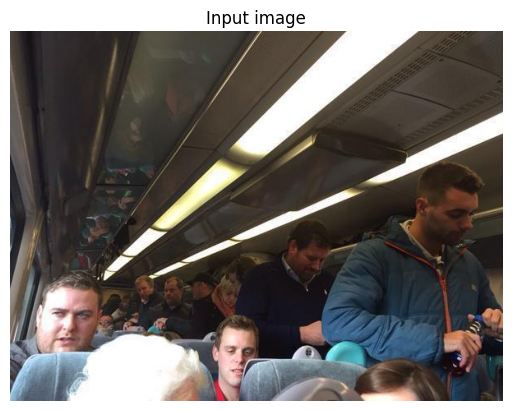

__________________________________________________
RESULTS
__________________________________________________
Predicted sentiment : neutral
Confidence score: 47.541

Channel wise predicted sentiment (text, image): (neutral,negative)

Channel wise predicted sentiment (text, image): (0.618,0.540)
__________________________________________________
Thank you!


In [9]:
# MELT("/kaggle/input/musait/basket_unique/negative_003.jpg", generate=1, print_info=True)
MELT("/kaggle/input/mvsasingle/MVSA_Single/data/10.jpg", generate=1, print_info=True)
# MELT_MVSA("/kaggle/input/mvsasingle/MVSA_Single/data/10.jpg", print_info=True)

# DocImSent dataset

In [13]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

root = "/kaggle/input/musait/dataset/basket"
directory = os.listdir(root)
directory.sort()
L = len(directory)

y_true, y_pred = [],[]

In [16]:
import os

def save_results(filename, cm, support, macro_precision, macro_recall, macro_f1, accuracy, report):
    # Create file name
    # if filename==None:
    #     filename = "MELT__DocImSent.txt"

    # Prepare formatted text
    content = f"""============================================================================
    Model Name: MELT
    ============================================================================
    Confusion Matrix:
    
              Pred 0  Pred 1  Pred 2
    Actual 0     {cm[0][0]}      {cm[0][1]}      {cm[0][2]}
    Actual 1      {cm[1][0]}     {cm[1][1]}      {cm[1][2]}
    Actual 2      {cm[2][0]}      {cm[2][1]}     {cm[2][2]}
    
    Support\t\t: {support}
    Macro precision\t: {macro_precision}
    Macro recall\t: {macro_recall}
    Macro F1\t: {macro_f1}
    Accuracy\t: {accuracy}
    
    Classification Report
    {report}
    """
    
    # Save to file
    with open(filename, "w") as f:
        f.write(content)

    print(f"Results saved to {filename}")

In [17]:
from sklearn.metrics import classification_report

def find_cm_cr(filename, y_true, y_pred):
    TP, FP, FN = [0]*3,[0]*3,[0]*3
    class_precision, class_recall, class_f1 = [0]*3,[0]*3,[0]*3
    classes = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    # print(cm)
    cm_df = pd.DataFrame(cm, index=[f"Actual: {c}" for c in classes],
                        columns=[f"Predicted: {c}" for c in classes])
    print("\nConfusion Matrix:")
    print(cm_df)

    report = classification_report(y_true, y_pred, digits=4) 
    print("Classification report")
    print(report)
    
    for idx, cls in enumerate(classes):
        TP = cm[idx, idx]
        FP = cm[:, idx].sum() - TP
        FN = cm[idx, :].sum() - TP
    
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        class_precision[idx] = precision,
        class_recall[idx] = recall,
        class_f1[idx] = f1
        
    macro_precision = sum(np.array(class_precision))/3
    macro_recall = sum(np.array(class_recall))/3
    macro_f1 = sum(np.array(class_f1))/3
    accuracy = np.trace(cm) / np.sum(cm)
    support = len(y_true)
    print(f"Support : {support}")
    print(f"Macro precision: {macro_precision[0]}")
    print(f"Macro recall: {macro_recall[0]}")
    print(f"Macro F1: {macro_f1}")
    print(f"Accuracy: {accuracy}")
    save_results(filename, cm, support, macro_precision, macro_recall, macro_f1, accuracy, report)

## with BLIP

In [24]:
print("-"*10,f"MELT Model being initiated","-"*10)

for fname in tqdm(directory, desc="Running inference of MELT on MuSAIT dataset"):
    filepath = os.path.join(root,fname)
    pred_class = MELT_B1(filepath, return_value=True)
    actual_sentiment = fname.split("_")[0]
    actual_class = SENTIMENTS_TO_LABELS[actual_sentiment]
    y_true += [actual_class]
    y_pred += [pred_class]

print("="*50)
print("Inference complete!")

---------- MELT Model being initiated ----------


Running inference of MELT on MuSAIT dataset:   0%|          | 0/2875 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Inference complete!


In [27]:
find_cm_cr("MELT__DocImSent_B1.txt", y_true, y_pred)


Confusion Matrix:
           Predicted: 0  Predicted: 1  Predicted: 2
Actual: 0           865            25            17
Actual: 1            22           912            13
Actual: 2            10            49           962
Classification report
              precision    recall  f1-score   support

           0     0.9643    0.9537    0.9590       907
           1     0.9249    0.9630    0.9436       947
           2     0.9698    0.9422    0.9558      1021

    accuracy                         0.9527      2875
   macro avg     0.9530    0.9530    0.9528      2875
weighted avg     0.9533    0.9527    0.9528      2875

Support : 2875
Macro precision: 0.9530109613733005
Macro recall: 0.95298273129379
Macro F1: 0.952792797923654
Accuracy: 0.952695652173913
Results saved to MELT__DocImSent.txt


## without BLIP

In [21]:
print("-"*10,f"MELT Model being initiated","-"*10)

for fname in tqdm(directory, desc="Running inference of MELT on MuSAIT dataset"):
    filepath = os.path.join(root,fname)
    pred_class = MELT_B0(filepath, return_value=True)
    actual_sentiment = fname.split("_")[0]
    actual_class = SENTIMENTS_TO_LABELS[actual_sentiment]
    y_true += [actual_class]
    y_pred += [pred_class]

print("="*50)
print("Inference complete!")

---------- MELT Model being initiated ----------


Running inference of MELT on MuSAIT dataset:   0%|          | 0/2875 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Inference complete!


In [22]:
find_cm_cr("MELT__DocImSent_B0", y_true, y_pred)


Confusion Matrix:
           Predicted: 0  Predicted: 1  Predicted: 2
Actual: 0           870            18            19
Actual: 1            27           907            13
Actual: 2            12            34           975
Classification report
              precision    recall  f1-score   support

           0     0.9571    0.9592    0.9581       907
           1     0.9458    0.9578    0.9517       947
           2     0.9682    0.9549    0.9615      1021

    accuracy                         0.9572      2875
   macro avg     0.9570    0.9573    0.9571      2875
weighted avg     0.9573    0.9572    0.9572      2875

Support : 2875
Macro precision: 0.9570316677856664
Macro recall: 0.9573045523604292
Macro F1: 0.9571398719602167
Accuracy: 0.9572173913043478
Results saved to MELT__DocImSent_B0


# MELT_MVSA

In [111]:
def MELT_MVSA(filepath, alpha=0.5, return_value=True, orientation=False, print_info=False):
    prob_text, prob_img = None, None
    pred_class_text, pred_class_img = None, None

    text = None
    # texts = check_text_detection(filepath)
    with open(filepath.split(".")[0]+".txt", 'r', encoding='latin-1') as file:
        text = file.read().strip()
    
    alpha = 0.5
    inputs = text_tokenizer(text, return_tensors="pt", 
                            truncation=True, 
                            padding=True, 
                            max_length=MAX_LENGTH).to(device)
    with torch.no_grad():
        outputs = text_model(**inputs)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=1)
    
    prob_text = np.array(probs.squeeze().tolist())
    pred_class_text = np.argmax(prob_text)

    image = None 
    image_preprocessed = None
    # try:
    image = Image.open(filepath)
    image_preprocessed = image_preprocess(image).unsqueeze(0).to(device)
    # except (OSError, UnidentifiedImageError, FileNotFoundError) as e:
    #     print(f"File: {filepath.split('/')[-1]} is an INVALID image file")
    #     return e
    # except Exception as e:
    #     print(f"Unexpected error: {e}")
    #     return e
        
    pred_class_clip = -1
    
    # Inference
    with torch.no_grad():
        output = image_model(image_preprocessed)
        # Get the predicted class index
        
        probs = F.softmax(output, dim=1)  # Shape: (1, 3)
        prob_img = np.array(probs.squeeze().tolist())  # Shape: (3,)
        pred_class_image = output.argmax(dim=1).item()

    
    prob_total = alpha * prob_text + (1 - alpha) * prob_img
    # print(f"prob_total = {alpha} * {prob_text} + ({1 - alpha}) * {prob_img} = {prob_total}")
    pred_class = np.argmax(prob_total)
    if print_info:
        plt.imshow(image)
        plt.axis('off')
        plt.title("Input image")
        plt.show()
        print("_"*50)
        print("RESULTS")
        print("_"*50)
        print(f"Given text = {text}")
        print()
        print(f"Predicted sentiment : {LABELS_TO_SENTIMENTS[pred_class]}")
        print(f"Confidence score: {prob_total[pred_class]*100:.3f}")
        print(f"\nChannel wise predicted sentiment (text, image): ({LABELS_TO_SENTIMENTS[pred_class_text]},{LABELS_TO_SENTIMENTS[pred_class_image]})")
        print(f"\nChannel wise predicted sentiment (text, image): ({prob_text[pred_class_text]:.3f},{prob_img[pred_class_image]:.3f})")
        print("_"*50)
        print("Thank you!")
    else:
        return pred_class_text, pred_class_image, pred_class

In [71]:
x = "/kaggle/input/mvsasingle/MVSA_Single/data/5129.jpg"
x.split(".")[0]+".txt"

'/kaggle/input/mvsasingle/MVSA_Single/data/5129.txt'

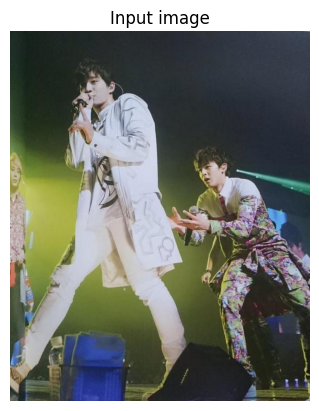

__________________________________________________
RESULTS
__________________________________________________
Given text = RT @khununeos: khun was literally me whenever I gotta see junho's sinful butt- lol (crtto) http://t.co/y3IvvUTRYT

Predicted sentiment : negative
Confidence score: 46.126

Channel wise predicted sentiment (text, image): (negative,neutral)

Channel wise predicted sentiment (text, image): (0.614,0.455)
__________________________________________________
Thank you!


In [72]:
MELT_MVSA("/kaggle/input/mvsasingle/MVSA_Single/data/5129.jpg", print_info=True)

In [59]:
t = os.listdir("/kaggle/input/mvsasingle/MVSA_Single/data")
print(len(t))
txt, jpg = 0,0
for f in t:
    jpg += 1 if "jpg" in f else 0
    txt += 1 if "txt" in f else 0

print(f"jpg = {jpg}")
print(f"txt = {txt}")

9738
jpg = 4869
txt = 4869


In [23]:
ind = 0
for f in t:
    if "txt" in f:
        print(f.split(".")[0], end=" ")
    if ind%10==0:
        print()
    ind += 1

1893 
1711 4682 5064 3504 1773 559 
1812 1093 4417 4503 1356 2869 3926 
2093 1880 3721 557 361 2842 1366 
1866 5020 1437 
992 3079 3851 5120 2658 
2975 3109 1038 40 1721 
812 1025 245 2588 870 655 
3749 4334 431 4424 
4439 2460 3975 44 3223 4099 
2957 574 4457 788 141 487 
1819 3577 571 
4703 4240 372 4146 
333 4235 3615 
4983 5101 1740 2875 4205 1009 
4384 1624 3931 540 2646 
528 2769 276 3303 604 3767 
1578 1687 1488 1117 1174 4488 
5018 1317 515 2099 3171 3 3043 
244 4373 1373 3083 
4820 2991 2070 1380 3214 
4454 4489 84 3089 3546 
1361 746 175 2926 2554 3520 4567 4843 
61 2463 69 1727 3407 
1181 2379 2013 351 
2915 1040 2098 30 
1262 3728 1604 
1586 2553 1193 
418 3429 4979 3874 2836 
4329 4093 586 4136 2403 
449 1748 3705 265 4376 2841 
2700 3886 874 178 201 464 
3607 2500 
1024 36 3301 2612 1129 
4587 251 122 3834 2664 1395 
1839 1547 4919 4628 1367 
1921 728 375 2927 
3986 2318 2602 687 3364 3205 3314 
47 3416 1651 5051 
3016 4392 2977 4660 982 
2986 2780 3272 4371 
3459 139 183

# MVSA Single

In [62]:
# Path to the input text file
input_path = '/kaggle/input/mvsasingle/MVSA_Single/labelResultAll.txt'

# Read the text file, skipping the first row (header)
df = pd.read_csv(input_path, sep='\t', skiprows=1, names=['ID', 'Sentiments'])

# Split the 'Sentiments' column into two separate columns
df[['txt_sentiment', 'img_sentiment']] = df['Sentiments'].str.split(',', expand=True)

# Drop the original 'Sentiments' column
df.drop(columns='Sentiments', inplace=True)

# Save to CSV (goes to the working directory in Kaggle)
output_csv = '/kaggle/working/mvsa-single_labels.csv'
df.to_csv(output_csv, index=False)

# Show some confirmation
print("CSV saved to:", output_csv)
print(df.head())
print("Total rows:", len(df))

total = len(df)

CSV saved to: /kaggle/working/mvsa-single_labels.csv
   ID txt_sentiment img_sentiment
0   1       neutral      positive
1   2       neutral      positive
2   3       neutral      positive
3   4      positive      positive
4   5      positive      positive
Total rows: 4869


In [41]:
ind = 0
c=0
for ids in df['ID']:
    if ids - 1 != ind:
        print(ind, ids)
        c+=1
    ind += 1
print(c)


# All IDs go in sequence until 2168. post 2168th (index = 2167) entry, the 2169th (index = 2168) entry onwards IDs start from 2311

2168 2311
2169 2312
2170 2313
2171 2314
2172 2318
2173 2319
2174 2320
2175 2321
2176 2322
2177 2323
2178 2324
2179 2325
2180 2326
2181 2327
2182 2328
2183 2329
2184 2330
2185 2331
2186 2332
2187 2333
2188 2334
2189 2335
2190 2336
2191 2337
2192 2338
2193 2339
2194 2340
2195 2345
2196 2346
2197 2348
2198 2349
2199 2350
2200 2351
2201 2354
2202 2355
2203 2356
2204 2357
2205 2358
2206 2359
2207 2360
2208 2361
2209 2362
2210 2363
2211 2364
2212 2365
2213 2366
2214 2367
2215 2368
2216 2369
2217 2370
2218 2371
2219 2372
2220 2373
2221 2374
2222 2375
2223 2376
2224 2377
2225 2378
2226 2379
2227 2380
2228 2381
2229 2382
2230 2383
2231 2384
2232 2385
2233 2386
2234 2387
2235 2388
2236 2389
2237 2403
2238 2404
2239 2424
2240 2425
2241 2426
2242 2427
2243 2428
2244 2429
2245 2430
2246 2431
2247 2432
2248 2433
2249 2434
2250 2435
2251 2436
2252 2437
2253 2438
2254 2439
2255 2440
2256 2441
2257 2442
2258 2443
2259 2444
2260 2445
2261 2446
2262 2447
2263 2448
2264 2449
2265 2450
2266 2451
2267 2452


In [56]:
print(4869 in df['ID']) # checks the indices
print(4869 in df['ID'].values) # checks within the list of df['ID']

False
True


In [51]:
df['ID'].dtype

dtype('int64')

In [52]:
val = df['ID'][4868]
print(val, type(val))

5129 <class 'numpy.int64'>


In [61]:
root = '/kaggle/input/mvsasingle/MVSA_Single/data'
all_files = os.listdir(root)
all_files = [file for file in all_files if '.jpg' in file]
all_files.sort()
print(len(all_files))

4869


In [73]:
y_true = []

for _, row in tqdm(df.iterrows(), total=total, desc="Extracting true sentiments of MVSA-Single dataset"):
    fname = f"{row['ID']}.jpg"
    txt_sentiment = row['txt_sentiment']
    img_sentiment = row['img_sentiment']
    actual_sentiments = (txt_sentiment, img_sentiment)
    y_true += [actual_sentiments]

Extracting true sentiments of MVSA-Single dataset:   0%|          | 0/4869 [00:00<?, ?it/s]

In [77]:
correct = 0
invalid = 0
y_true_1 = []
y_pred_single = []

for _, row in tqdm(df.iterrows(), total=total, desc="Running inference of MELT on MVSA-Single dataset"):
    fname = f"{row['ID']}.jpg"
    txt_sentiment = row['txt_sentiment']
    img_sentiment = row['img_sentiment']
    fpath = os.path.join(root, fname)
    
    # print(fname)
    try:
        pred_class_text, pred_class_image, pred_class = MELT_MVSA(fpath, return_value=True)
    except FileNotFoundError:
        invalid += 1
        continue
    except UnidentifiedImageError:
        invalid += 1
        continue
    actual_sentiments = (txt_sentiment, img_sentiment)
    # actual_sentiments = y_true[_]
    y_true_1 += [actual_sentiments]
    
    pred_text_sentiment = LABELS_TO_SENTIMENTS[pred_class_text]
    pred_image_sentiment = LABELS_TO_SENTIMENTS[pred_class_image]
    pred_sentiment = LABELS_TO_SENTIMENTS[pred_class]
    # print(f"actual sentiments: {actual_sentiments}")
    # print(f"predicted sentiments (text, image, fused): {pred_sentiment, pred_text_sentiment, pred_image_sentiment}")
    decision1 = pred_text_sentiment in actual_sentiments
    decision2 = pred_image_sentiment in actual_sentiments
    decision3 = pred_sentiment in actual_sentiments
    decision = decision1 or decision2 or decision3
    # y_pred_single += [pred_text_sentiment] if decision1 else [pred_image_sentiment] if decision2 else [pred_sentiment]
    # print(f"Decision 1: {decision1}")
    # print(f"Decision 2: {decision2}")
    # print(f"Decision 3: {decision3}")
    # print(f"Final decision: {decision}")
    if decision:
        correct += 1
    # print(f"yes {correct}/({_+1})")
    # print("="*50)
    # if _ == 10:
    #     break

Running inference of MELT on MVSA-Single dataset:   0%|          | 0/4869 [00:00<?, ?it/s]

In [90]:
all_files[100:105]

['1089.jpg', '109.jpg', '1090.jpg', '1091.jpg', '1092.jpg']

In [79]:
invalid

0

In [78]:
correct

3860

In [80]:
print(f"Accuracy: {(correct/total):.3f}")

Accuracy: 0.793


# MVSA Multiple

In [85]:
import pandas as pd

# Path to the new input text file
input_path = '/kaggle/input/mvsamultiple/MVSA/labelResultAll.txt'

# Read the file with tab separator
df_1 = pd.read_csv(input_path, sep='\t')
print(df_1.head())
print("Columns detected:", df_1.columns)
print("Shape of DataFrame:", df_1.shape)

# Rename the columns for clarity
df_1.columns = ['ID', 'annotator1', 'annotator2', 'annotator3']

# Split each annotator column into text and image sentiment
df_1[['txt1', 'img1']] = df_1['annotator1'].str.split(',', expand=True)
df_1[['txt2', 'img2']] = df_1['annotator2'].str.split(',', expand=True)
df_1[['txt3', 'img3']] = df_1['annotator3'].str.split(',', expand=True)

# Drop the original annotator columns
df_1.drop(columns=['annotator1', 'annotator2', 'annotator3'], inplace=True)

# Save the cleaned dataframe to CSV
output_csv = '/kaggle/working/mvsa-multiple_labels.csv'
df_1.to_csv(output_csv, index=False)

# Show confirmation
print("CSV saved to:", output_csv)
print(df_1.head())
print("Total rows:", len(df_1))

     ID         text,image       text,image.1       text,image.2
0  2499  positive,positive    neutral,neutral  positive,positive
1  2500   neutral,positive  positive,positive    neutral,neutral
2  2501  negative,negative    neutral,neutral  positive,positive
3  2502  positive,positive  positive,positive  positive,positive
4  2503   positive,neutral  positive,negative  positive,positive
Columns detected: Index(['ID', 'text,image', 'text,image.1', 'text,image.2'], dtype='object')
Shape of DataFrame: (19600, 4)
CSV saved to: /kaggle/working/mvsa-multiple_labels.csv
     ID      txt1      img1      txt2      img2      txt3      img3
0  2499  positive  positive   neutral   neutral  positive  positive
1  2500   neutral  positive  positive  positive   neutral   neutral
2  2501  negative  negative   neutral   neutral  positive  positive
3  2502  positive  positive  positive  positive  positive  positive
4  2503  positive   neutral  positive  negative  positive  positive
Total rows: 19600


In [86]:
10000 in df_1.ID.values

True

In [91]:
print(19601 in df_1['ID']) # checks the indices
print(19601 in df_1['ID'].values) # checks within the list of df['ID']

False
True


In [92]:
df_1['ID'].dtype

dtype('int64')

In [94]:
val = df_1['ID'][19599]
print(val, type(val))

22891 <class 'numpy.int64'>


In [95]:
root = '/kaggle/input/mvsamultiple/MVSA/data'
all_files = os.listdir(root)
all_files = [file for file in all_files if '.jpg' in file]
all_files.sort()
print(len(all_files))

19600


In [96]:
y_true_multiple = []

for _, row in tqdm(df_1.iterrows(), total=total, desc="Extracting true sentiments of MVSA-Multiple dataset"):
    fname = f"{row['ID']}.jpg"
    txt1 = row['txt1']
    img1 = row['img1']
    txt2 = row['txt1']
    img2 = row['img1']
    txt3 = row['txt1']
    img3 = row['img1']
    actual_sentiments = (txt1, img1, txt2, img2, txt3, img3)
    y_true_multiple += [actual_sentiments]

Extracting true sentiments of MVSA-Multiple dataset:   0%|          | 0/4869 [00:00<?, ?it/s]

In [98]:
for _, row in tqdm(df_1.iterrows(), total=total, desc="Running inference of MELT on MVSA-Multiple dataset"):
    print(type(_))
    break

Running inference of MELT on MVSA-Multiple dataset:   0%|          | 0/4869 [00:00<?, ?it/s]

<class 'int'>


In [99]:
y_true_multiple[:5]

[('positive', 'positive', 'positive', 'positive', 'positive', 'positive'),
 ('neutral', 'positive', 'neutral', 'positive', 'neutral', 'positive'),
 ('negative', 'negative', 'negative', 'negative', 'negative', 'negative'),
 ('positive', 'positive', 'positive', 'positive', 'positive', 'positive'),
 ('positive', 'neutral', 'positive', 'neutral', 'positive', 'neutral')]

In [101]:
len(df_1)

19600

In [113]:
correct_mvsam = 0
invalid = 0
total_mvsam = len(df_1)

for _, row in tqdm(df_1.iterrows(), total=total_mvsam, desc="Running inference of MELT on MVSA-Multiple dataset"):
    fname = f"{row['ID']}.jpg"
    fpath = os.path.join(root, fname)
    
    # print(fname)
    try:
        pred_class_text, pred_class_image, pred_class = MELT_MVSA(fpath, return_value=True)
    except FileNotFoundError:
        invalid += 1
        continue
    except UnidentifiedImageError:
        invalid += 1
        continue
    except OSError:
        invalid += 1
    # actual_sentiments = (txt_sentiment, img_sentiment)
    actual_sentiments = y_true_multiple[_]
    # y_true_1 += [actual_sentiments]
    
    pred_text_sentiment = LABELS_TO_SENTIMENTS[pred_class_text]
    pred_image_sentiment = LABELS_TO_SENTIMENTS[pred_class_image]
    pred_sentiment = LABELS_TO_SENTIMENTS[pred_class]
    # print(f"actual sentiments: {actual_sentiments}")
    # print(f"predicted sentiments (text, image, fused): {pred_sentiment, pred_text_sentiment, pred_image_sentiment}")
    decision1 = pred_text_sentiment in actual_sentiments
    decision2 = pred_image_sentiment in actual_sentiments
    decision3 = pred_sentiment in actual_sentiments
    decision = decision1 or decision2 or decision3
    # print(f"Decision 1: {decision1}")
    # print(f"Decision 2: {decision2}")
    # print(f"Decision 3: {decision3}")
    # print(f"Final decision: {decision}")
    if decision:
        correct_mvsam += 1
    # print(f"yes {correct}/({_+1})")
    # print("="*50)
    # if _ == 10:
    #     break

Running inference of MELT on MVSA-Multiple dataset:   0%|          | 0/19600 [00:00<?, ?it/s]

In [114]:
invalid

4

In [115]:
correct_mvsam

14165

In [117]:
total_mvsam

19600

In [118]:
print(f"Accuracy: {(correct_mvsam/(total_mvsam-invalid)):.3f}")

Accuracy: 0.723
